# epica Benchmark Analysis

This notebook is a lightweight workspace for reading an existing benchmark run. It does not rerun `epica`; it only loads `summary.csv`, finds suspicious cases, and sketches the plots that are useful enough to later turn into a static report.

Install the analysis dependencies if needed:

```bash
python -m pip install 'epica[analysis]'
```

For local repository development, use:

```bash
python -m pip install -e '.[analysis]'
```

## 1. Configure the Run

By default, the notebook uses the newest `outputs/alignanything_bench/run_*` directory. Set `RUN_DIR_OVERRIDE` if you want to inspect a specific run.

In [10]:
from pathlib import Path

RUN_DIR_OVERRIDE = None
BENCH_ROOT = Path("../outputs/alignanything_bench").resolve()

def find_latest_run(root):
    candidates = sorted(
        [path for path in root.glob("run_*") if (path / "summary.csv").exists()],
        key=lambda path: path.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(f"No benchmark runs with summary.csv found under {root}")
    return candidates[-1]

RUN_DIR = Path(RUN_DIR_OVERRIDE).expanduser().resolve() if RUN_DIR_OVERRIDE else find_latest_run(BENCH_ROOT)
SUMMARY_CSV = RUN_DIR / "summary.csv"
CASES_DIR = RUN_DIR / "cases"
PLOTS_DIR = RUN_DIR / "plots"

print(f"Using run: {RUN_DIR}")
assert SUMMARY_CSV.exists(), f"Missing summary.csv: {SUMMARY_CSV}"

Using run: /home/yifu/epa/outputs/alignanything_bench/run_20260425_020846


## 2. Load and Normalize

In [11]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Install notebook dependencies with: python -m pip install -e '.[analysis]'"
    ) from exc

df = pd.read_csv(SUMMARY_CSV)

numeric_cols = [
    "epa_offset_est_s",
    "evo_offset_s",
    "epa_ate_rmse_raw_m",
    "epa_ate_rmse_step3_m",
    "evo_ape_raw_rmse_m",
    "evo_ape_se3_rmse_m",
    "epa_improve_pct",
    "evo_improve_pct",
    "epa_xcorr_peak",
    "epa_xcorr_psr",
    "epa_omega_improve_pct",
    "epa_matches_equivalent",
    "evo_matches",
    "evo_sweep_evals",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "dataset" not in df.columns:
    df["dataset"] = "unknown"
if "method" not in df.columns:
    df["method"] = "unknown"

has_tool_comparison = {"evo_ape_se3_rmse_m", "epa_ate_rmse_step3_m"}.issubset(df.columns)

df.head()

,case,dataset,method,status,gt,est,epa_status,evo_status,epa_offset_est_s,evo_offset_s,...,epa_xcorr_peak,epa_xcorr_psr,epa_omega_improve_pct,epa_matches_equivalent,evo_matches,epa_run_dir,epa_stdout_log,epa_stderr_log,evo_sweep_evals,error
0,euroc_mav_MH_01_easy_rovio,euroc_mav,rovio,ok,GT/euroc_mav/MH_01_easy.txt,benchmark/euroc_mav/pose/rovio/MH_01_easy/rovi...,ok,ok,-0.002,0.05,...,0.985891,15.029583,0.484679,3638.0,3639.0,/home/yifu/epa/outputs/run_20260425_020847,/home/yifu/epa/outputs/alignanything_bench/run...,/home/yifu/epa/outputs/alignanything_bench/run...,102,NaN
1,euroc_mav_MH_02_easy_rovio,euroc_mav,rovio,ok,GT/euroc_mav/MH_02_easy.txt,benchmark/euroc_mav/pose/rovio/MH_02_easy/rovi...,ok,ok,-0.002,20.00,...,0.971551,14.968276,0.334428,3000.0,2618.0,/home/yifu/epa/outputs/run_20260425_020913,/home/yifu/epa/outputs/alignanything_bench/run...,/home/yifu/epa/outputs/alignanything_bench/run...,92,NaN
2,euroc_mav_MH_03_medium_rovio,euroc_mav,rovio,ok,GT/euroc_mav/MH_03_medium.txt,benchmark/euroc_mav/pose/rovio/MH_03_medium/ro...,ok,ok,-0.001,0.15,...,0.983942,10.524226,0.047752,2631.0,2631.0,/home/yifu/epa/outputs/run_20260425_020937,/home/yifu/epa/outputs/alignanything_bench/run...,/home/yifu/epa/outputs/alignanything_bench/run...,102,NaN
3,euroc_mav_MH_04_difficult_rovio,euroc_mav,rovio,ok,GT/euroc_mav/MH_04_difficult.txt,benchmark/euroc_mav/pose/rovio/MH_04_difficult...,ok,ok,-0.003,-20.00,...,0.968874,13.963726,0.428305,1976.0,1597.0,/home/yifu/epa/outputs/run_20260425_020955,/home/yifu/epa/outputs/alignanything_bench/run...,/home/yifu/epa/outputs/alignanything_bench/run...,92,NaN
4,euroc_mav_MH_05_difficult_rovio,euroc_mav,rovio,ok,GT/euroc_mav/MH_05_difficult.txt,benchmark/euroc_mav/pose/rovio/MH_05_difficult...,ok,ok,-0.001,20.00,...,0.973932,14.538690,0.022790,2222.0,1849.0,/home/yifu/epa/outputs/run_20260425_021009,/home/yifu/epa/outputs/alignanything_bench/run...,/home/yifu/epa/outputs/alignanything_bench/run...,92,NaN


## 3. Run Summary

In [12]:
def metric_summary(series):
    series = series.dropna()
    if series.empty:
        return {"count": 0, "mean": np.nan, "median": np.nan, "p90": np.nan, "max": np.nan}
    return {
        "count": int(series.shape[0]),
        "mean": series.mean(),
        "median": series.median(),
        "p90": series.quantile(0.90),
        "max": series.max(),
    }

summary_rows = [
    {"metric": "cases", "value": len(df)},
    {"metric": "datasets", "value": df["dataset"].nunique()},
    {"metric": "methods", "value": df["method"].nunique()},
]

if "epa_ate_rmse_step3_m" in df.columns:
    for name, value in metric_summary(df["epa_ate_rmse_step3_m"]).items():
        summary_rows.append({"metric": f"epica aligned RMSE {name}", "value": value})

if "epa_improve_pct" in df.columns:
    for name, value in metric_summary(df["epa_improve_pct"]).items():
        summary_rows.append({"metric": f"epica improvement % {name}", "value": value})

display(pd.DataFrame(summary_rows))

if "status" in df.columns:
    display(df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="cases"))

,metric,value
0,cases,1.390000e+02
1,datasets,4.000000e+00
2,methods,3.000000e+00
3,epica aligned RMSE count,1.390000e+02
4,epica aligned RMSE mean,2.228246e+04
5,epica aligned RMSE median,1.695618e+00
6,epica aligned RMSE p90,4.358922e+03
7,epica aligned RMSE max,1.197500e+06
8,epica improvement % count,1.390000e+02
9,epica improvement % mean,7.755060e+01


,status,cases
0,ok,139


## 4. Dataset and Method Breakdown

In [13]:
def grouped_summary(group_cols):
    agg = {"case": "count"}
    if "epa_ate_rmse_step3_m" in df.columns:
        agg["epa_ate_rmse_step3_m"] = ["median", "mean", "max"]
    if "epa_improve_pct" in df.columns:
        agg["epa_improve_pct"] = ["median", "mean"]
    if "epa_matches_equivalent" in df.columns:
        agg["epa_matches_equivalent"] = ["median", "min"]

    out = df.groupby(group_cols, dropna=False).agg(agg)
    out.columns = ["_".join([p for p in col if p]) for col in out.columns.to_flat_index()]
    return out.reset_index().sort_values("case_count", ascending=False)

display(grouped_summary(["dataset"]))
display(grouped_summary(["method"]))
display(grouped_summary(["dataset", "method"]))

,dataset,case_count,epa_ate_rmse_step3_m_median,epa_ate_rmse_step3_m_mean,epa_ate_rmse_step3_m_max,epa_improve_pct_median,epa_improve_pct_mean,epa_matches_equivalent_median,epa_matches_equivalent_min
1,grand_tour,68,3.764538,4392.245211,2.316466e+05,86.063561,75.617582,4040.0,805.0
3,uzh_fpv,30,0.640114,1.057641,9.236636e+00,96.856805,94.638229,1037.0,446.0
0,euroc_mav,22,0.156618,1770.742449,3.895219e+04,96.443743,92.128803,2231.0,1671.0
2,lamaria,19,4358.921549,145242.163388,1.197500e+06,19.265162,40.608289,3224.0,0.0


,method,case_count,epa_ate_rmse_step3_m_median,epa_ate_rmse_step3_m_mean,epa_ate_rmse_step3_m_max,epa_improve_pct_median,epa_improve_pct_mean,epa_matches_equivalent_median,epa_matches_equivalent_min
0,rovio,60,3.470522,5037.072808,2.316466e+05,85.577527,76.304062,2559.0,446.0
2,svo_stereo,60,0.825390,590.606150,3.531437e+04,96.819634,90.495540,2386.5,446.0
1,svo_mono,19,4358.921549,145242.163388,1.197500e+06,19.265162,40.608289,3224.0,0.0


,dataset,method,case_count,epa_ate_rmse_step3_m_median,epa_ate_rmse_step3_m_mean,epa_ate_rmse_step3_m_max,epa_improve_pct_median,epa_improve_pct_mean,epa_matches_equivalent_median,epa_matches_equivalent_min
2,grand_tour,rovio,34,9.146275,7742.704480,2.316466e+05,71.573877,64.827344,4070.5,819.0
3,grand_tour,svo_stereo,34,1.258104,1041.785943,3.531437e+04,94.761044,86.407821,4001.5,805.0
4,lamaria,svo_mono,19,4358.921549,145242.163388,1.197500e+06,19.265162,40.608289,3224.0,0.0
5,uzh_fpv,rovio,15,0.528507,1.154846,9.236636e+00,97.196880,94.184644,1037.0,446.0
6,uzh_fpv,svo_stereo,15,0.731576,0.960436,1.855676e+00,96.809126,95.091813,1037.0,446.0
1,euroc_mav,svo_stereo,11,0.129432,0.112764,1.728294e-01,97.785550,96.862663,2208.0,1671.0
0,euroc_mav,rovio,11,0.265708,3541.372133,3.895219e+04,95.506034,87.394944,2240.0,1671.0


## 5. Quick Figures

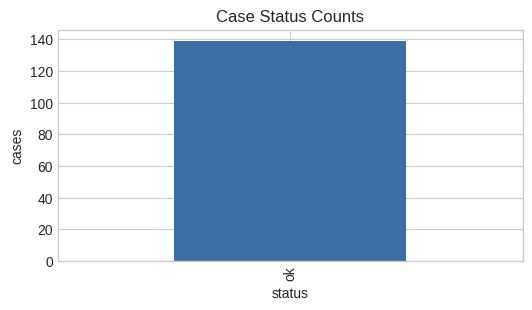

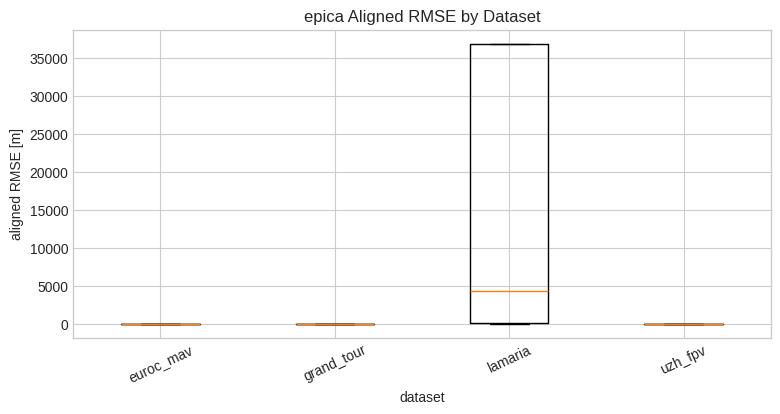

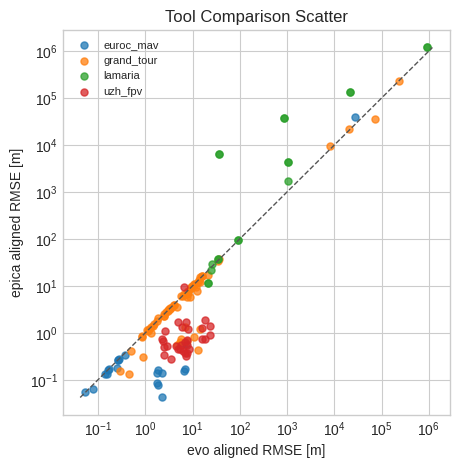

In [14]:
for style_name in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid"):
    if style_name in plt.style.available:
        plt.style.use(style_name)
        break


if "status" in df.columns:
    counts = df["status"].value_counts().sort_index()
    ax = counts.plot(kind="bar", figsize=(6, 3), color="#3a6ea5")
    ax.set_title("Case Status Counts")
    ax.set_xlabel("status")
    ax.set_ylabel("cases")
    plt.show()

def box_stats(label, values):
    values = np.asarray(values, dtype=float)
    q1, med, q3 = np.percentile(values, [25, 50, 75])
    iqr = q3 - q1
    lo = values[values >= q1 - 1.5 * iqr].min()
    hi = values[values <= q3 + 1.5 * iqr].max()
    fliers = values[(values < lo) | (values > hi)]
    return {"label": label, "whislo": lo, "q1": q1, "med": med, "q3": q3, "whishi": hi, "fliers": fliers}

if "epa_ate_rmse_step3_m" in df.columns:
    stats = []
    for name, part in df.groupby("dataset", dropna=False):
        values = part["epa_ate_rmse_step3_m"].dropna().to_numpy(dtype=float)
        if len(values):
            stats.append(box_stats(str(name), values))
    if stats:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.bxp(stats, showfliers=False)
        ax.set_title("epica Aligned RMSE by Dataset")
        ax.set_xlabel("dataset")
        ax.set_ylabel("aligned RMSE [m]")
        ax.tick_params(axis="x", rotation=25)
        plt.show()

if has_tool_comparison:
    comp = df[["epa_ate_rmse_step3_m", "evo_ape_se3_rmse_m", "dataset", "method"]].dropna()
    comp = comp[(comp["epa_ate_rmse_step3_m"] > 0) & (comp["evo_ape_se3_rmse_m"] > 0)]
    if not comp.empty:
        lo = min(comp["epa_ate_rmse_step3_m"].min(), comp["evo_ape_se3_rmse_m"].min())
        hi = max(comp["epa_ate_rmse_step3_m"].max(), comp["evo_ape_se3_rmse_m"].max())
        fig, ax = plt.subplots(figsize=(5, 5))
        for dataset, part in comp.groupby("dataset"):
            ax.scatter(part["evo_ape_se3_rmse_m"], part["epa_ate_rmse_step3_m"], s=26, alpha=0.75, label=dataset)
        ax.plot([lo, hi], [lo, hi], color="#555", linewidth=1, linestyle="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("evo aligned RMSE [m]")
        ax.set_ylabel("epica aligned RMSE [m]")
        ax.set_title("Tool Comparison Scatter")
        ax.legend(fontsize=8)
        plt.show()

## 6. Case Browser

This table is intentionally simple. Change `sort_col`, `dataset_filter`, or `method_filter` while exploring.

In [15]:
dataset_filter = None
method_filter = None
status_filter = None
sort_col = "epa_ate_rmse_step3_m"
ascending = False
top_n = 25

view = df.copy()
if dataset_filter:
    view = view[view["dataset"] == dataset_filter]
if method_filter:
    view = view[view["method"] == method_filter]
if status_filter and "status" in view.columns:
    view = view[view["status"] == status_filter]

preferred_cols = [
    "case",
    "dataset",
    "method",
    "status",
    "epa_ate_rmse_step3_m",
    "epa_improve_pct",
    "epa_offset_est_s",
    "epa_xcorr_psr",
    "epa_matches_equivalent",
    "evo_ape_se3_rmse_m",
    "evo_matches",
    "error",
]
display_cols = [col for col in preferred_cols if col in view.columns]
if sort_col in view.columns:
    view = view.sort_values(sort_col, ascending=ascending)

display(view[display_cols].head(top_n))

,case,dataset,method,status,epa_ate_rmse_step3_m,epa_improve_pct,epa_offset_est_s,epa_xcorr_psr,epa_matches_equivalent,evo_ape_se3_rmse_m,evo_matches,error
97,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,1.197500e+06,19.265162,0.025,16.521404,0.0,915750.508417,2209.0,NaN
105,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,1.197500e+06,19.265162,0.025,16.521404,0.0,915750.508417,2209.0,NaN
34,grand_tour_2024-11-11-12-07-40_rovio,grand_tour,rovio,ok,2.316466e+05,21.404854,-0.006,21.792497,9593.0,231366.821652,9401.0,NaN
96,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,1.337477e+05,0.380133,0.013,26.083677,3883.0,21425.686275,3852.0,NaN
104,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,1.337477e+05,0.380133,0.013,26.083677,3883.0,21425.686275,3852.0,NaN
1,euroc_mav_MH_02_easy_rovio,euroc_mav,rovio,ok,3.895219e+04,27.742517,-0.002,14.968276,3000.0,28047.708079,2618.0,NaN
101,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.689006e+04,-0.375484,-0.051,3.715018,2553.0,868.297225,2877.0,NaN
93,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.689006e+04,-0.375484,-0.051,3.715018,2553.0,868.297225,2877.0,NaN
84,grand_tour_2024-11-18-15-46-05_svo_stereo,grand_tour,svo_stereo,ok,3.531437e+04,1.028396,-0.003,7.496295,1331.0,73993.196548,1331.0,NaN
46,grand_tour_2024-11-15-14-14-12_rovio,grand_tour,rovio,ok,2.165280e+04,26.774553,-0.002,13.345797,5415.0,20538.060507,5220.0,NaN


## 7. Suspicious Cases

The notebook builds a simple suspiciousness score from rank-normalized signals. Higher means the case is more worth inspecting.

In [16]:
def add_rank_score(frame, col, higher_is_worse=True, weight=1.0):
    if col not in frame.columns:
        return pd.Series(0.0, index=frame.index)
    values = frame[col]
    if values.notna().sum() == 0:
        return pd.Series(0.0, index=frame.index)
    ranks = values.rank(pct=True, ascending=not higher_is_worse)
    return ranks.fillna(0.0) * weight

score_parts = []
score_parts.append(add_rank_score(df, "epa_ate_rmse_step3_m", higher_is_worse=True, weight=3.0))
score_parts.append(add_rank_score(df, "epa_improve_pct", higher_is_worse=False, weight=1.5))
score_parts.append(add_rank_score(df, "epa_matches_equivalent", higher_is_worse=False, weight=1.0))
score_parts.append(add_rank_score(df, "epa_xcorr_psr", higher_is_worse=False, weight=1.0))

df["suspicious_score"] = sum(score_parts)

if has_tool_comparison:
    df["epica_vs_evo_delta_m"] = df["epa_ate_rmse_step3_m"] - df["evo_ape_se3_rmse_m"]
    df["epica_vs_evo_ratio"] = df["epa_ate_rmse_step3_m"] / df["evo_ape_se3_rmse_m"]
    df["suspicious_score"] += add_rank_score(df, "epica_vs_evo_delta_m", higher_is_worse=True, weight=1.0)

suspicious_cols = [
    "case",
    "dataset",
    "method",
    "status",
    "suspicious_score",
    "epa_ate_rmse_step3_m",
    "epa_improve_pct",
    "epa_matches_equivalent",
    "epa_xcorr_psr",
    "epica_vs_evo_delta_m",
    "epica_vs_evo_ratio",
]
suspicious_cols = [col for col in suspicious_cols if col in df.columns]

display(df.sort_values("suspicious_score", ascending=False)[suspicious_cols].head(15))

def show_top(title, sort_col, ascending=False, n=10):
    if sort_col not in df.columns:
        return
    cols = [
        "case",
        "dataset",
        "method",
        "status",
        sort_col,
        "suspicious_score",
        "epa_ate_rmse_step3_m",
        "epa_improve_pct",
        "epa_xcorr_psr",
        "epa_matches_equivalent",
    ]
    cols = list(dict.fromkeys([col for col in cols if col in df.columns]))
    print(title)
    display(df.sort_values(sort_col, ascending=ascending)[cols].head(n))

show_top("Highest aligned RMSE", "epa_ate_rmse_step3_m", ascending=False)
show_top("Lowest match count", "epa_matches_equivalent", ascending=True)
show_top("Lowest cross-correlation PSR", "epa_xcorr_psr", ascending=True)
show_top("Largest epica minus evo RMSE", "epica_vs_evo_delta_m", ascending=False)

,case,dataset,method,status,suspicious_score,epa_ate_rmse_step3_m,epa_improve_pct,epa_matches_equivalent,epa_xcorr_psr,epica_vs_evo_delta_m,epica_vs_evo_ratio
16,euroc_mav_V1_01_easy_svo_stereo,euroc_mav,svo_stereo,ok,6.208633,0.041407,98.967610,2874.0,13.183697,-2.184874,0.018599
12,euroc_mav_MH_02_easy_svo_stereo,euroc_mav,svo_stereo,ok,6.028777,0.064334,98.894119,2999.0,14.710644,-0.012374,0.838685
15,euroc_mav_MH_05_difficult_svo_stereo,euroc_mav,svo_stereo,ok,5.996403,0.171757,98.951748,2192.0,14.481289,-6.788427,0.024677
14,euroc_mav_MH_04_difficult_svo_stereo,euroc_mav,svo_stereo,ok,5.960432,0.152285,99.022503,1953.0,13.877743,-6.535589,0.022770
11,euroc_mav_MH_01_easy_svo_stereo,euroc_mav,svo_stereo,ok,5.874101,0.129432,97.907395,3621.0,14.934307,-0.023018,0.849011
80,grand_tour_2024-11-15-14-14-12_svo_stereo,grand_tour,svo_stereo,ok,5.805755,0.675115,98.799616,5415.0,12.429515,-7.059251,0.087288
75,grand_tour_2024-11-14-16-04-09_svo_stereo,grand_tour,svo_stereo,ok,5.780576,1.216538,98.537471,4882.0,18.171861,-12.959093,0.085819
67,grand_tour_2024-11-04-16-05-00_svo_stereo,grand_tour,svo_stereo,ok,5.589928,0.429196,99.040016,2056.0,12.337937,-12.771527,0.032513
5,euroc_mav_V1_01_easy_rovio,euroc_mav,rovio,ok,5.568345,0.137035,96.637934,2894.0,13.079102,-2.055207,0.062509
18,euroc_mav_V1_03_difficult_svo_stereo,euroc_mav,svo_stereo,ok,5.374101,0.085040,97.395278,2076.0,9.316693,-1.691392,0.047871


Highest aligned RMSE


,case,dataset,method,status,epa_ate_rmse_step3_m,suspicious_score,epa_improve_pct,epa_xcorr_psr,epa_matches_equivalent
97,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,1.197500e+06,1.019784,19.265162,16.521404,0.0
105,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,1.197500e+06,1.019784,19.265162,16.521404,0.0
34,grand_tour_2024-11-11-12-07-40_rovio,grand_tour,rovio,ok,2.316466e+05,2.230216,21.404854,21.792497,9593.0
96,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,1.337477e+05,1.843525,0.380133,26.083677,3883.0
104,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,1.337477e+05,1.843525,0.380133,26.083677,3883.0
1,euroc_mav_MH_02_easy_rovio,euroc_mav,rovio,ok,3.895219e+04,1.672662,27.742517,14.968276,3000.0
101,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.689006e+04,0.714029,-0.375484,3.715018,2553.0
93,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.689006e+04,0.714029,-0.375484,3.715018,2553.0
84,grand_tour_2024-11-18-15-46-05_svo_stereo,grand_tour,svo_stereo,ok,3.531437e+04,1.708633,1.028396,7.496295,1331.0
46,grand_tour_2024-11-15-14-14-12_rovio,grand_tour,rovio,ok,2.165280e+04,1.967626,26.774553,13.345797,5415.0


Lowest match count


,case,dataset,method,status,epa_matches_equivalent,suspicious_score,epa_ate_rmse_step3_m,epa_improve_pct,epa_xcorr_psr
106,lamaria_R_11_5cp_svo_mono,lamaria,svo_mono,ok,0.0,2.877698,2.116320e+01,95.491416,14.909593
97,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,0.0,1.019784,1.197500e+06,19.265162,16.521404
105,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,0.0,1.019784,1.197500e+06,19.265162,16.521404
133,uzh_fpv_outdoor_forward_5_snapdragon_with_gt_r...,uzh_fpv,rovio,ok,446.0,4.366906,9.048401e-01,98.679516,4.626967
136,uzh_fpv_outdoor_forward_5_snapdragon_with_gt_s...,uzh_fpv,svo_stereo,ok,446.0,3.910072,1.365958e+00,97.917300,4.620695
138,uzh_fpv_outdoor_45_1_snapdragon_with_gt_svo_st...,uzh_fpv,svo_stereo,ok,498.0,4.730216,2.729876e-01,98.131705,5.723035
137,uzh_fpv_outdoor_45_1_snapdragon_with_gt_rovio,uzh_fpv,rovio,ok,507.0,4.075540,4.937009e-01,96.100197,5.754826
111,uzh_fpv_indoor_forward_5_snapdragon_with_gt_rovio,uzh_fpv,rovio,ok,530.0,4.557554,4.068048e-01,98.083035,3.492662
117,uzh_fpv_indoor_forward_5_snapdragon_with_gt_sv...,uzh_fpv,svo_stereo,ok,530.0,3.320144,1.297702e+00,93.271824,3.507321
114,uzh_fpv_indoor_forward_9_snapdragon_with_gt_rovio,uzh_fpv,rovio,ok,767.0,4.773381,3.716613e-01,97.868419,6.279324


Lowest cross-correlation PSR


,case,dataset,method,status,epa_xcorr_psr,suspicious_score,epa_ate_rmse_step3_m,epa_improve_pct,epa_matches_equivalent
111,uzh_fpv_indoor_forward_5_snapdragon_with_gt_rovio,uzh_fpv,rovio,ok,3.492662,4.557554,0.406805,98.083035,530.0
117,uzh_fpv_indoor_forward_5_snapdragon_with_gt_sv...,uzh_fpv,svo_stereo,ok,3.507321,3.320144,1.297702,93.271824,530.0
101,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.715018,0.714029,36890.058994,-0.375484,2553.0
93,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,3.715018,0.714029,36890.058994,-0.375484,2553.0
24,grand_tour_2024-11-02-17-10-25_rovio,grand_tour,rovio,ok,4.149681,2.478417,1.766415,78.286018,1785.0
58,grand_tour_2024-11-02-17-10-25_svo_stereo,grand_tour,svo_stereo,ok,4.209277,5.104317,0.129104,98.275230,1786.0
121,uzh_fpv_indoor_45_12_snapdragon_with_gt_rovio,uzh_fpv,rovio,ok,4.408956,1.456835,9.236636,50.636310,1077.0
126,uzh_fpv_indoor_45_12_snapdragon_with_gt_svo_st...,uzh_fpv,svo_stereo,ok,4.442374,3.607914,0.731576,92.864531,1077.0
136,uzh_fpv_outdoor_forward_5_snapdragon_with_gt_s...,uzh_fpv,svo_stereo,ok,4.620695,3.910072,1.365958,97.917300,446.0
133,uzh_fpv_outdoor_forward_5_snapdragon_with_gt_r...,uzh_fpv,rovio,ok,4.626967,4.366906,0.904840,98.679516,446.0


Largest epica minus evo RMSE


,case,dataset,method,status,epica_vs_evo_delta_m,suspicious_score,epa_ate_rmse_step3_m,epa_improve_pct,epa_xcorr_psr,epa_matches_equivalent
97,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,281749.477154,1.019784,1.197500e+06,19.265162,16.521404,0.0
105,lamaria_sequence_4_11_svo_mono,lamaria,svo_mono,ok,281749.477154,1.019784,1.197500e+06,19.265162,16.521404,0.0
104,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,112322.008091,1.843525,1.337477e+05,0.380133,26.083677,3883.0
96,lamaria_sequence_4_10_svo_mono,lamaria,svo_mono,ok,112322.008091,1.843525,1.337477e+05,0.380133,26.083677,3883.0
93,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,36021.761769,0.714029,3.689006e+04,-0.375484,3.715018,2553.0
101,lamaria_sequence_2_12_svo_mono,lamaria,svo_mono,ok,36021.761769,0.714029,3.689006e+04,-0.375484,3.715018,2553.0
1,euroc_mav_MH_02_easy_rovio,euroc_mav,rovio,ok,10904.481425,1.672662,3.895219e+04,27.742517,14.968276,3000.0
94,lamaria_sequence_3_17_svo_mono,lamaria,svo_mono,ok,6231.704751,2.347122,6.268453e+03,0.022051,26.882594,5893.0
102,lamaria_sequence_3_17_svo_mono,lamaria,svo_mono,ok,6231.704751,2.347122,6.268453e+03,0.022051,26.882594,5893.0
92,lamaria_sequence_2_11_svo_mono,lamaria,svo_mono,ok,3305.868607,2.070144,4.358922e+03,2.148152,24.267085,3848.0


## 8. Drill Into One Case

By default this opens the highest-scoring suspicious case. Set `CASE` to a case name if you want a specific one.

In [17]:
import json

CASE = None

if CASE is None:
    if "suspicious_score" in df.columns:
        CASE = df.sort_values("suspicious_score", ascending=False).iloc[0]["case"]
    elif "epa_ate_rmse_step3_m" in df.columns:
        CASE = df.sort_values("epa_ate_rmse_step3_m", ascending=False).iloc[0]["case"]
    else:
        CASE = df.iloc[0]["case"]

case_json = CASES_DIR / f"{CASE}.json"
print(CASE)
print(case_json)

case_row = df[df["case"] == CASE]
if not case_row.empty:
    display(case_row[[col for col in suspicious_cols if col in case_row.columns]])

if case_json.exists():
    with open(case_json, "r", encoding="utf-8") as f:
        case_data = json.load(f)
    display(case_data)
else:
    print("No case JSON found for this case.")

euroc_mav_V1_01_easy_svo_stereo
/home/yifu/epa/outputs/alignanything_bench/run_20260425_020846/cases/euroc_mav_V1_01_easy_svo_stereo.json


,case,dataset,method,status,suspicious_score,epa_ate_rmse_step3_m,epa_improve_pct,epa_matches_equivalent,epa_xcorr_psr,epica_vs_evo_delta_m,epica_vs_evo_ratio
16,euroc_mav_V1_01_easy_svo_stereo,euroc_mav,svo_stereo,ok,6.208633,0.041407,98.96761,2874.0,13.183697,-2.184874,0.018599


{'case': 'euroc_mav_V1_01_easy_svo_stereo',
 'dataset': 'euroc_mav',
 'method': 'svo_stereo',
 'sequence': 'V1_01_easy',
 'gt_path': '/home/yifu/epa_data/AlignAnything/AlignAnything/GT/euroc_mav/V1_01_easy.txt',
 'est_path': '/home/yifu/epa_data/AlignAnything/AlignAnything/benchmark/euroc_mav/pose/svo_stereo/V1_01_easy/svo_poses.txt',
 'status': 'ok',
 'offset_policy': 'epa_internal + evo_independent_sweep',
 'gt_prepared_tum': '/home/yifu/epa/outputs/alignanything_bench/run_20260425_020846/prepared_tum/euroc_mav_V1_01_easy_svo_stereo__gt.tum',
 'est_prepared_tum': '/home/yifu/epa/outputs/alignanything_bench/run_20260425_020846/prepared_tum/euroc_mav_V1_01_easy_svo_stereo__est.tum',
 'epa': {'status': 'ok',
  'returncode': 0,
  'stdout_log': '/home/yifu/epa/outputs/alignanything_bench/run_20260425_020846/logs/epa/euroc_mav_V1_01_easy_svo_stereo.stdout.log',
  'stderr_log': '/home/yifu/epa/outputs/alignanything_bench/run_20260425_020846/logs/epa/euroc_mav_V1_01_easy_svo_stereo.stderr.lo

## 9. Existing Plot Files

,plot
0,aligned_rmse_by_dataset_box.png
1,aligned_rmse_scatter_log.png
2,benchmark_study_aligned_rmse_ecdf.png
3,benchmark_study_aligned_rmse_scatter.png
4,benchmark_study_dataset_boxplot.png
5,benchmark_study_improvement_box.png
6,benchmark_study_win_tie_loss_stacked.png
7,improve_pct_scatter.png
8,matches_scatter_log.png
9,offset_distribution.png


aligned_rmse_by_dataset_box.png


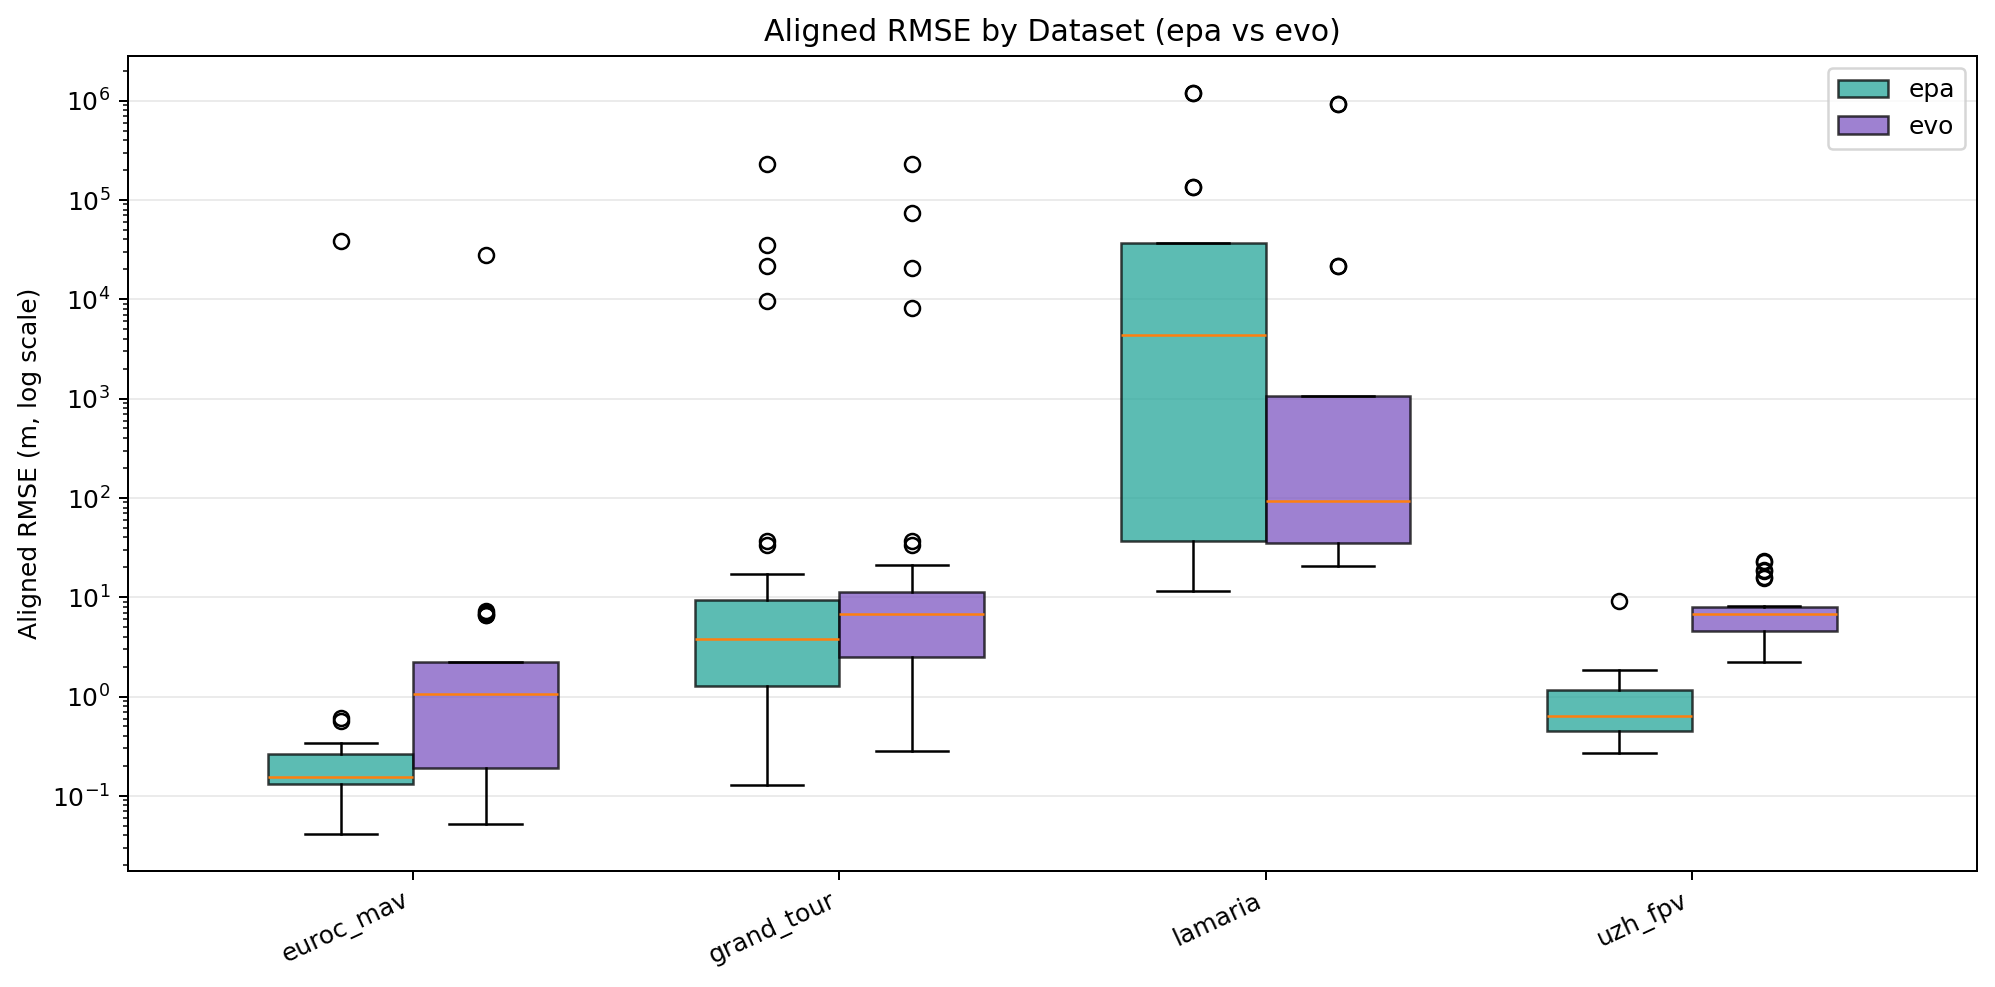

aligned_rmse_scatter_log.png


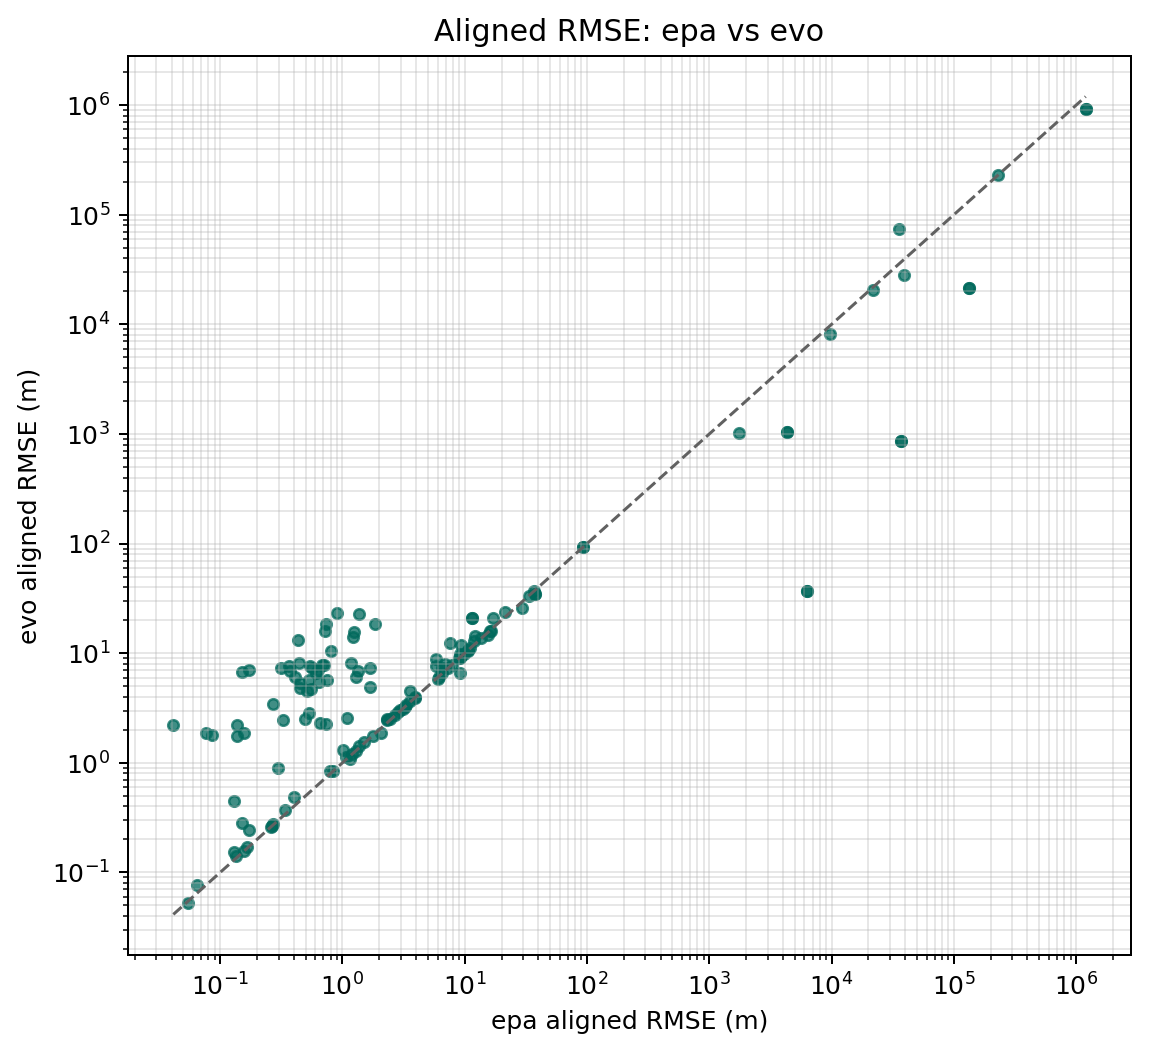

benchmark_study_aligned_rmse_ecdf.png


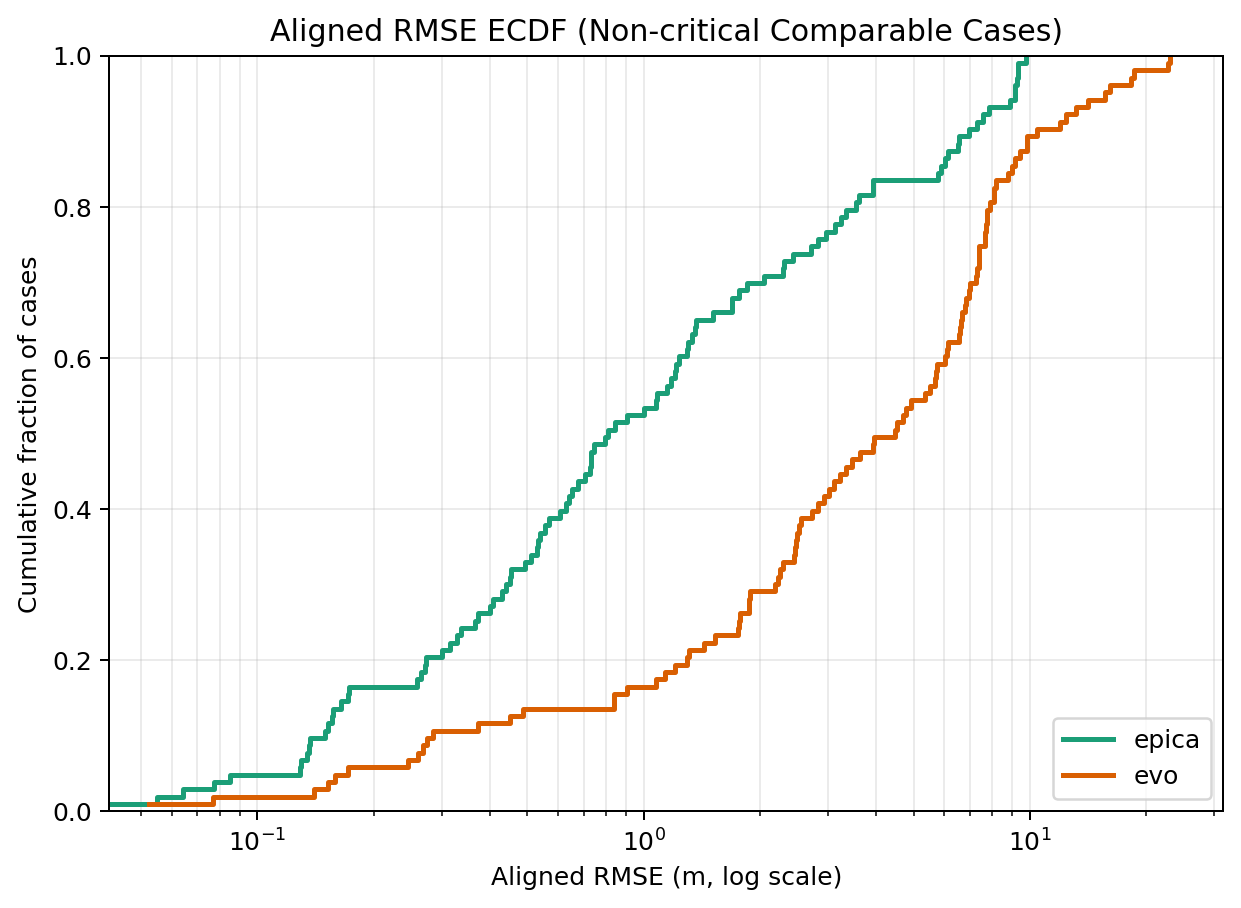

benchmark_study_aligned_rmse_scatter.png


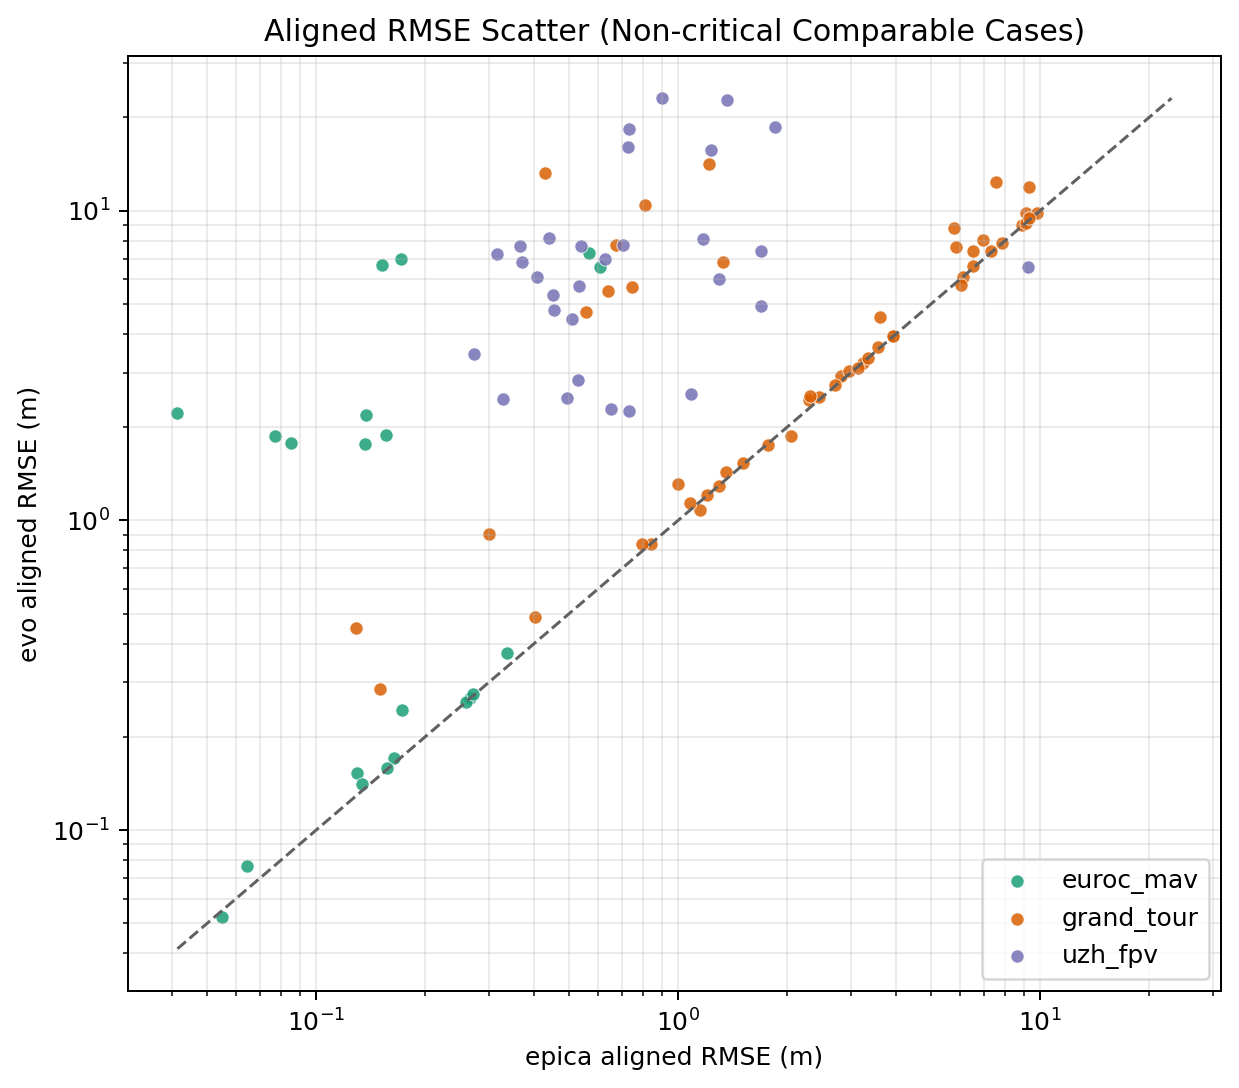

benchmark_study_dataset_boxplot.png


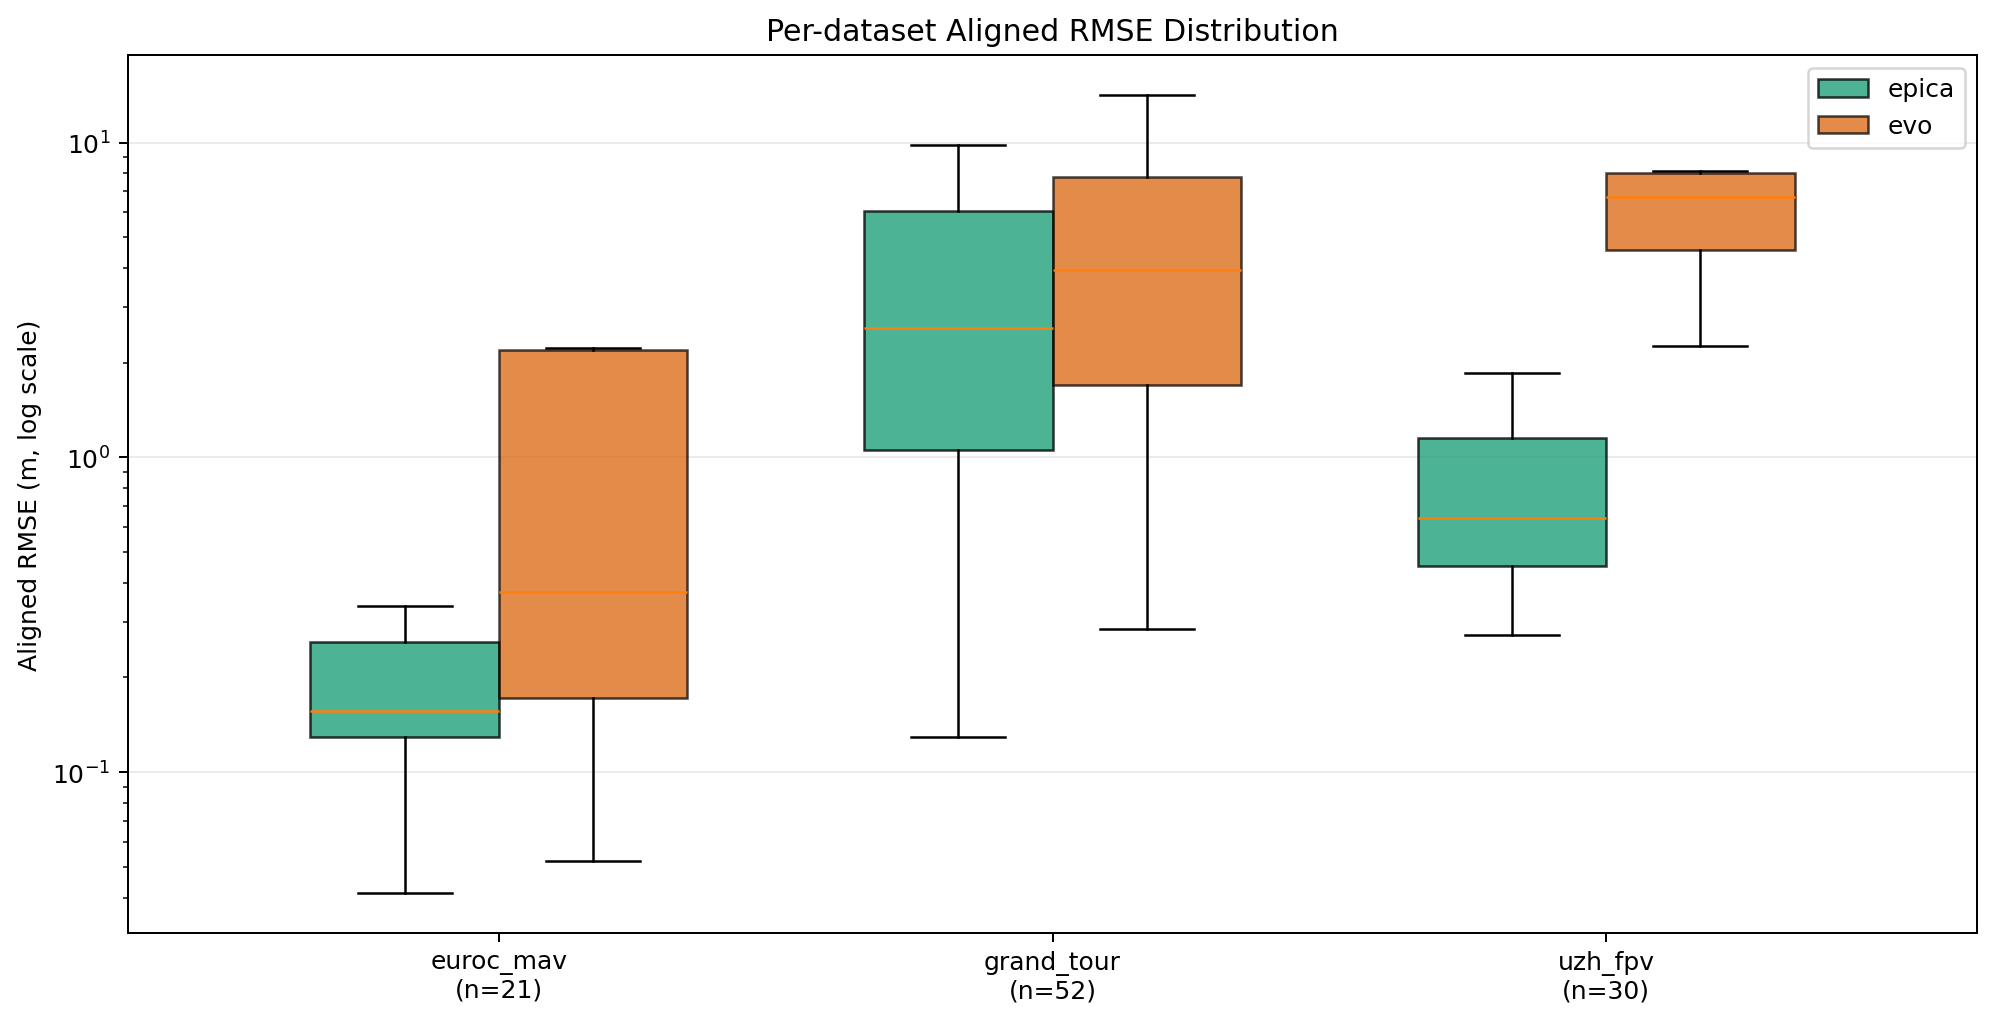

benchmark_study_improvement_box.png


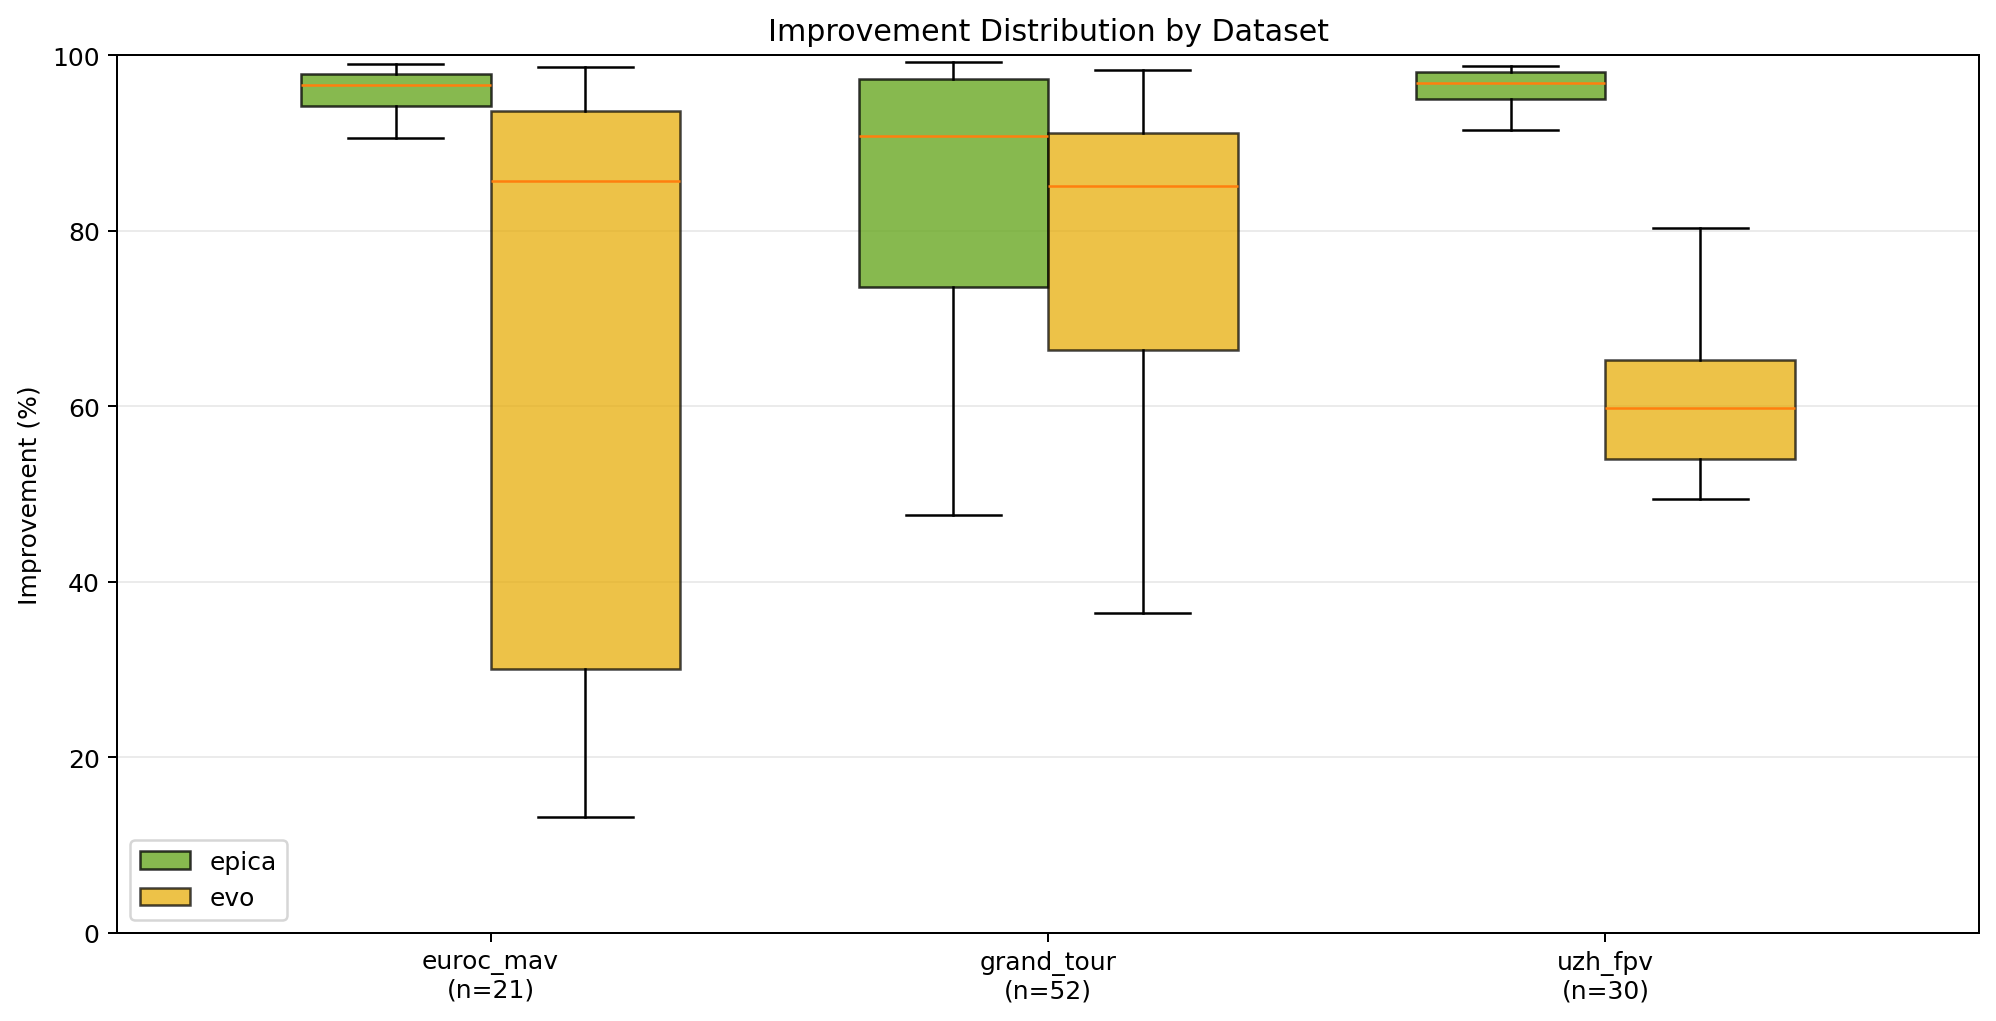

In [18]:
from IPython.display import Image

plot_files = sorted(PLOTS_DIR.glob("*.png")) if PLOTS_DIR.exists() else []
display(pd.DataFrame({"plot": [p.name for p in plot_files]}))

for plot in plot_files[:6]:
    print(plot.name)
    display(Image(filename=str(plot), width=720))

## 10. Report Candidates

After exploring a few runs, these are the views most likely to deserve a permanent `epa_bench_report` page:

- run summary cards
- dataset and method breakdown tables
- sortable case browser
- suspicious-case lists
- optional tool comparison scatter and ECDF when comparison columns are available